# Real Estate Price Intelligence System

## House Price Prediction using Machine Learning

### Author: Disha Goyal

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Project Overview

The objective of this project is to build a machine learning-based real estate price prediction system that can estimate house prices based on various property features such as location, area, number of bedrooms, bathrooms, and balconies.

The project includes:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Building
- Model Evaluation
- Interactive Price Prediction System

## Dataset Loading

The Bengaluru House Price dataset contains information about residential properties including location, area type, square footage, number of bathrooms, balconies, and selling price.

In [2]:
df = pd.read_csv('/content/Train.csv')

## Dataset Inspection

In this section, we examine the structure of the dataset, identify data types, and detect missing values that may require preprocessing.

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.shape

(13320, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [7]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


### Initial Observations

- Dataset contains 13,320 records.
- Total features: 9
- Target variable: Price
- Significant missing values are present in the society column.
- Minor missing values exist in location, size, bath, and balcony columns.

In [8]:
df.duplicated().sum()

np.int64(529)

### Duplicate Records Analysis

The dataset contains 529 duplicate records.

Duplicate entries can negatively impact model performance by introducing bias and reducing data quality.

These duplicate rows will be removed during the data preprocessing phase.

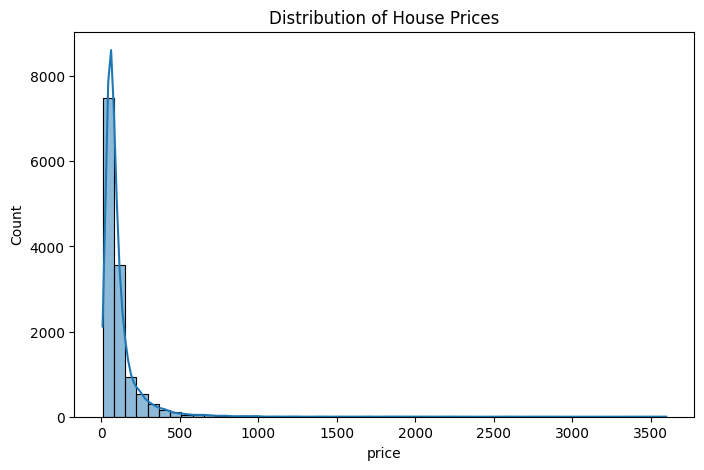

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.show()

In [10]:
df['price'].describe()

,price
count,13320.000000
mean,112.565627
std,148.971674
min,8.000000
25%,50.000000
50%,72.000000
75%,120.000000
max,3600.000000


### Observation

- The distribution of house prices is heavily right-skewed.
- Most properties are concentrated in the lower and mid-price range.
- A small number of extremely expensive properties create a long tail on the right side of the distribution.
- The maximum price (3600 Lakhs) is significantly higher than the median price (72 Lakhs), indicating the presence of outliers.
- Outlier treatment will be necessary before model training to improve prediction performance.

In [11]:
print("Mean Price :", round(df['price'].mean(),2))
print("Median Price :", round(df['price'].median(),2))
print("Maximum Price :", df['price'].max())

Mean Price : 112.57
Median Price : 72.0
Maximum Price : 3600.0


### Statistical Insight

The mean house price is considerably higher than the median price, confirming that the dataset contains high-value luxury properties which may act as outliers.

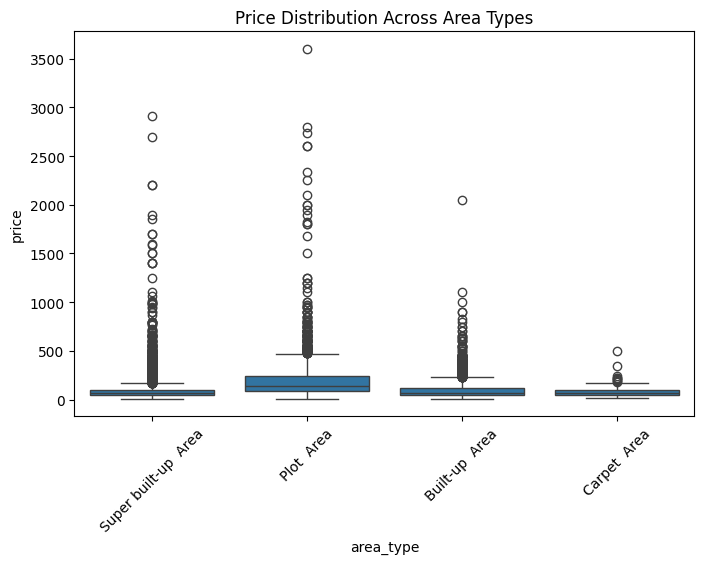

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='area_type',
    y='price',
    data=df
)

plt.xticks(rotation=45)
plt.title("Price Distribution Across Area Types")
plt.show()

### Observation

- Plot Area properties generally have a higher median price compared to other area types.
- Super built-up Area and Built-up Area properties are concentrated in the mid-price range.
- A large number of high-price outliers are present across all area types.
- Area type appears to have a significant influence on property pricing and should be retained as a feature for model training.

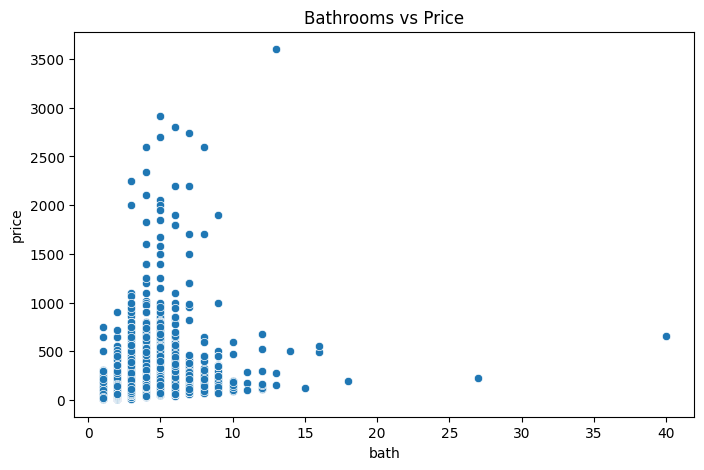

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='bath',
    y='price',
    data=df
)

plt.title("Bathrooms vs Price")
plt.show()

### Observation

- Properties with more bathrooms generally tend to have higher prices.
- Most houses contain between 2 and 6 bathrooms.
- Several extreme observations are visible, including properties with more than 20 bathrooms.
- These unusual records may represent luxury properties or data anomalies and will require outlier analysis.

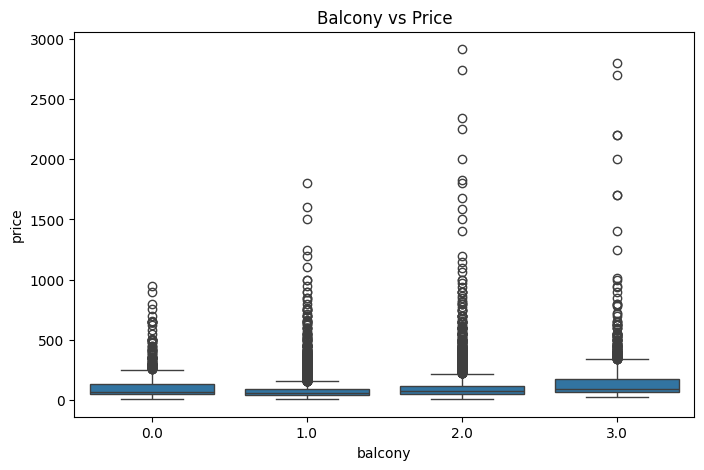

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='balcony',
    y='price',
    data=df
)

plt.title("Balcony vs Price")
plt.show()

### Observation

- Houses with more balconies tend to show a slightly higher median price.
- The relationship between balcony count and price is weaker than the relationship between bathrooms and price.
- Multiple high-value outliers exist across all balcony categories.
- Balcony count may contribute to prediction performance but is unlikely to be the strongest predictor.

# Data Cleaning and Preprocessing

The objective of this phase is to improve data quality by handling missing values, duplicate records, and inconsistencies before model development.

In [15]:
df = df.drop_duplicates()

print(df.shape)

(12791, 9)


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df = df.drop('society', axis=1)

### Society Column Removal

The society column contained a large number of missing values (over 40% of records).

To avoid introducing noise and unreliable imputations, the column was removed from the dataset.

In [18]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
total_sqft,0
bath,73
balcony,605
price,0


In [19]:
df = df.dropna()

In [20]:
df.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0


In [21]:
df.shape

(12185, 8)

### Missing Value Treatment

Missing values were identified in location, size, bath, and balcony features.

Since the number of missing records was relatively small compared to the overall dataset size, rows containing missing values were removed to maintain data quality and consistency.

# Feature Engineering

Feature engineering is performed to extract meaningful information from existing variables and improve model performance.

In [22]:
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

In [23]:
df[['size','bhk']].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


### BHK Feature Creation

The size column contained textual information such as "2 BHK" and "4 Bedroom".

A new numerical feature named bhk was extracted to represent the number of bedrooms, making it suitable for machine learning models.

In [24]:
df['total_sqft'].unique()[:20]

array(['1056', '2600', '1440', '1521', '1200', '1170', '1310', '1800',
       '2785', '1000', '1100', '2250', '1175', '1180', '1540', '2770',
       '600', '1755', '2800', '1767'], dtype=object)

In [25]:
def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

df[~df['total_sqft'].apply(is_float)].head(20)

,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk
30,Super built-up Area,19-Dec,Yelahanka,4 BHK,2100 - 2850,4.0,0.0,186.000,4
122,Super built-up Area,18-Mar,Hebbal,4 BHK,3067 - 8156,4.0,0.0,477.000,4
137,Super built-up Area,19-Mar,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,0.0,54.005,2
165,Super built-up Area,18-Dec,Sarjapur,2 BHK,1145 - 1340,2.0,0.0,43.490,2
188,Super built-up Area,Ready To Move,KR Puram,2 BHK,1015 - 1540,2.0,0.0,56.800,2
410,Super built-up Area,Ready To Move,Kengeri,1 BHK,34.46Sq. Meter,1.0,0.0,18.500,1
549,Super built-up Area,18-Sep,Hennur Road,2 BHK,1195 - 1440,2.0,0.0,63.770,2
661,Super built-up Area,Ready To Move,Yelahanka,2 BHK,1120 - 1145,2.0,0.0,48.130,2
672,Built-up Area,18-Mar,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,0.0,445.000,4
772,Super built-up Area,20-Dec,Banashankari Stage VI,2 BHK,1160 - 1195,2.0,0.0,59.935,2


### Area Feature Investigation

The total_sqft column was inspected for inconsistencies and non-standard formats.

Since property area is one of the most influential predictors of house price, careful preprocessing was required before model training.

### Handling Inconsistent Area Measurements

The total_sqft feature contained multiple formats, including:

- Single numeric values
- Area ranges (e.g., 2100-2850)
- Alternative measurement units (e.g., Sq. Meter, Acres)

Range values were converted to their average area, while a small number of inconsistent unit formats were removed to maintain feature consistency.

In [26]:
def convert_sqft_to_num(x):

    tokens = str(x).split('-')

    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1]))/2

    try:
        return float(x)

    except:
        return None

In [27]:
df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

In [28]:
df['total_sqft'].isnull().sum()

np.int64(42)

In [29]:
df = df.dropna()

In [30]:
df.shape

(12143, 9)

In [31]:
df['total_sqft'].isnull().sum()
df.shape

(12143, 9)

In [32]:
df['total_sqft'].isnull().sum()

np.int64(0)

### Price Per Square Foot Feature

Price per square foot is one of the most important indicators in real estate analytics.

This feature normalizes property prices based on area and helps identify unusually expensive or unusually cheap properties.

In [33]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

In [34]:
df[['price','total_sqft','price_per_sqft']].head()

,price,total_sqft,price_per_sqft
0,39.07,1056.0,3699.810606
1,120.00,2600.0,4615.384615
2,62.00,1440.0,4305.555556
3,95.00,1521.0,6245.890861
4,51.00,1200.0,4250.000000


In [35]:
df['price_per_sqft'].describe()

,price_per_sqft
count,1.214300e+04
mean,6.952226e+03
std,2.310936e+04
min,2.678298e+02
25%,4.275291e+03
50%,5.416667e+03
75%,7.228537e+03
max,2.300000e+06


### Price Per Square Foot Analysis

Price per square foot was calculated to normalize house prices with respect to property size.

The analysis revealed significant variability and the presence of extreme outliers, indicating the need for outlier detection and removal before model training.

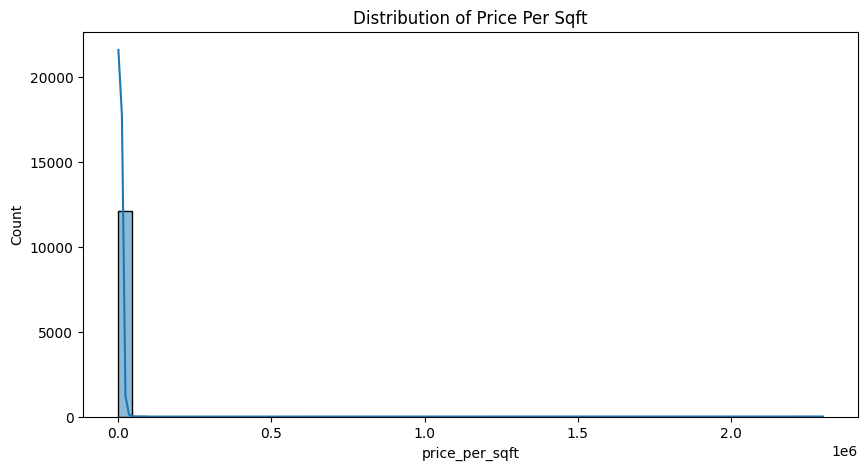

In [36]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['price_per_sqft'],
    bins=50,
    kde=True
)

plt.title("Distribution of Price Per Sqft")
plt.show()

In [37]:
df[df['total_sqft']/df['bhk'] < 300].head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft
58,Plot Area,Ready To Move,Murugeshpalya,6 Bedroom,1407.0,4.0,1.0,150.0,6,10660.980810
68,Plot Area,Ready To Move,Devarachikkanahalli,8 Bedroom,1350.0,7.0,0.0,85.0,8,6296.296296
70,Plot Area,Ready To Move,Double Road,3 Bedroom,500.0,3.0,2.0,100.0,3,20000.000000
78,Built-up Area,Ready To Move,Kaval Byrasandra,2 BHK,460.0,1.0,0.0,22.0,2,4782.608696
89,Plot Area,Ready To Move,Rajaji Nagar,6 Bedroom,710.0,6.0,3.0,160.0,6,22535.211268


In [38]:
df[df['total_sqft']/df['bhk'] < 300].shape

(645, 10)

### Outlier Detection Using Domain Knowledge

In real estate, a property is expected to provide a reasonable living area per bedroom.

Properties with less than 300 square feet per bedroom were identified as unrealistic and treated as outliers.

This rule-based filtering helps improve model reliability and prediction accuracy.

In [39]:
df = df[df['total_sqft']/df['bhk'] >= 300]

In [40]:
df.shape

(11498, 10)

### Dataset Size After Outlier Removal

After applying the minimum area-per-bedroom rule (300 sqft per bedroom), 645 unrealistic records were removed.

The cleaned dataset now contains 11,498 properties and is expected to provide more reliable patterns for model training.

In [41]:
df['sqft_per_bhk'] = df['total_sqft'] / df['bhk']

In [42]:
df[['total_sqft','bhk','sqft_per_bhk']].head()

,total_sqft,bhk,sqft_per_bhk
0,1056.0,2,528.0
1,2600.0,4,650.0
2,1440.0,3,480.0
3,1521.0,3,507.0
4,1200.0,2,600.0


In [43]:
len(df['location'].unique())

1182

### sqft_per_bhk Feature

A new feature named sqft_per_bhk was created by dividing total area by the number of bedrooms.

This feature captures the average space available per bedroom and provides additional information about property spaciousness that is not available from total area or bedroom count alone.

In [44]:
df['location'] = df['location'].apply(lambda x: x.strip())

In [45]:
location_stats = df.groupby('location')['location'].agg('count').sort_values(ascending=False)

location_stats.head(20)

,location
location,
Whitefield,496
Sarjapur Road,349
Electronic City,280
Kanakpura Road,234
Thanisandra,227
Yelahanka,199
Hebbal,157
Marathahalli,155
Raja Rajeshwari Nagar,155


### Location Standardization

The location feature was cleaned by removing leading and trailing spaces.

Since location is one of the most influential factors affecting house prices, proper standardization is essential before encoding and model training.

In [46]:
len(location_stats[location_stats <= 10])

962

In [47]:
location_stats[location_stats <= 10]

,location
location,
Giri Nagar,10
Bommenahalli,10
Gunjur Palya,10
Tindlu,10
Doddakallasandra,10
...,...
3rd Stage Raja Rajeshwari Nagar,1
3rd Phase Iti Layout,1
3rd Block HBR Layout,1


### Location Frequency Analysis

The dataset contains a large number of unique locations.

Many locations occur only a few times, which may lead to overfitting when applying one-hot encoding.

Rare locations will be grouped into a common category to improve model generalization.

### Rare Location Handling

Out of 1182 unique locations, 962 locations appeared 10 times or fewer.

To reduce dimensionality and improve model generalization, rare locations were grouped into a common category named "other".

In [48]:
location_stats_less_than_10 = location_stats[location_stats <= 10]

In [49]:
df['location'] = df['location'].apply(
    lambda x: 'other' if x in location_stats_less_than_10 else x
)

In [50]:
len(df['location'].unique())

211

### Location Consolidation

After grouping rare locations into the "other" category, the number of unique locations reduced from 1182 to 211.

This helped reduce dimensionality and improved the robustness of the predictive model.

In [51]:
def remove_pps_outliers(df):

    df_out = pd.DataFrame()

    for key, subdf in df.groupby('location'):

        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)

        reduced_df = subdf[
            (subdf.price_per_sqft > (m - st))
            &
            (subdf.price_per_sqft <= (m + st))
        ]

        df_out = pd.concat([df_out, reduced_df], ignore_index=True)

    return df_out

### Location-wise Price Per Square Foot Outlier Removal

Property prices vary significantly across locations.

Instead of applying a global threshold, outliers were removed based on the mean and standard deviation of price per square foot within each location.

This approach preserves local market characteristics while eliminating unrealistic observations.

In [52]:
df = remove_pps_outliers(df)

In [53]:
df.shape

(9463, 11)

### Location-wise Outlier Removal Results

After applying location-specific price-per-square-foot filtering, the dataset size reduced from 11,498 to 9,463 records.

This process eliminated extreme pricing anomalies while preserving realistic market behavior for each location.

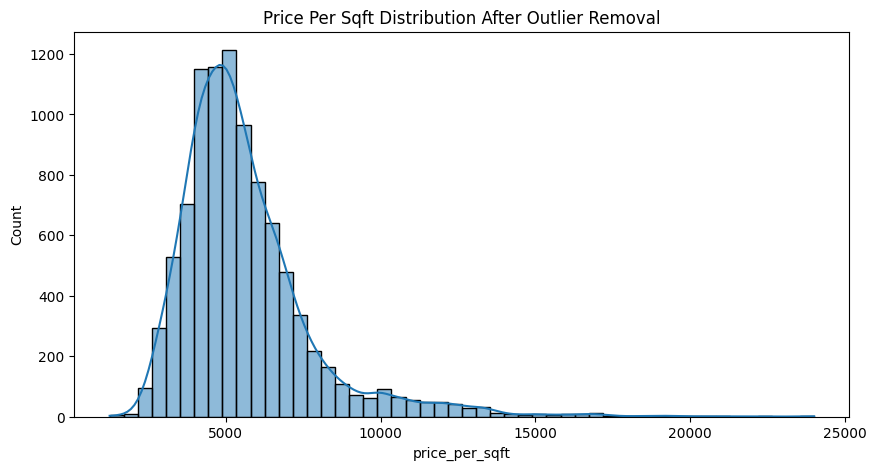

In [54]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['price_per_sqft'],
    bins=50,
    kde=True
)

plt.title("Price Per Sqft Distribution After Outlier Removal")
plt.show()

### Impact of Outlier Removal

After location-wise outlier filtering, the distribution of price per square foot became significantly more consistent.

Extreme pricing anomalies were removed, resulting in a cleaner dataset that better represents realistic market conditions.

### BHK-Based Outlier Removal

A location-wise BHK outlier removal strategy was applied.

For each location, the average price per square foot of a BHK category was compared with the previous BHK category.

Properties whose price per square foot was significantly lower than comparable lower-BHK properties in the same location were identified as anomalies and removed.

This helped improve dataset consistency and ensured that larger houses were not unrealistically priced below similar smaller houses.

In [55]:
def remove_bhk_outliers(df):

    exclude_indices = np.array([])

    for location, location_df in df.groupby('location'):

        bhk_stats = {}

        for bhk, bhk_df in location_df.groupby('bhk'):

            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }

        for bhk, bhk_df in location_df.groupby('bhk'):

            stats = bhk_stats.get(bhk-1)

            if stats and stats['count'] > 5:

                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[
                        bhk_df.price_per_sqft < stats['mean']
                    ].index.values
                )

    return df.drop(exclude_indices, axis='index')

In [56]:
df = remove_bhk_outliers(df)

df.shape

(6626, 11)

### Results of BHK Outlier Removal

The dataset size reduced from 9,463 to 6,626 records after removing inconsistent BHK-price relationships.

This step improved the overall quality of the dataset by eliminating unrealistic pricing patterns that could negatively impact model performance.

In [57]:
df.shape

(6626, 11)

In [58]:
df['price_per_sqft'].describe()

,price_per_sqft
count,6626.000000
mean,6111.958640
std,2300.462114
min,1300.000000
25%,4655.646880
50%,5714.285714
75%,6878.354524
max,24000.000000


In [59]:
df['bhk'].describe()


,bhk
count,6626.000000
mean,2.463628
std,0.870804
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,13.000000


# Final Dataset Quality Assessment

After multiple stages of preprocessing and outlier removal, the dataset is evaluated to ensure that realistic property characteristics and pricing patterns have been retained.

### Final Dataset Assessment

After multiple stages of preprocessing and outlier removal, the dataset exhibited a significantly more realistic distribution of property characteristics.

Key observations:

- Median price per square foot: ₹5,714
- Average price per square foot: ₹6,112
- Most properties fall within the 2–3 BHK category
- Extreme pricing anomalies were successfully removed
- The final dataset is suitable for predictive modeling

In [60]:
df_model = df.drop(
    ['size','availability','price_per_sqft','sqft_per_bhk'],
    axis=1
)

In [61]:
df_model.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
1,Super built-up Area,1st Phase JP Nagar,1875.0,3.0,1.0,167.0,3
2,Super built-up Area,1st Phase JP Nagar,2065.0,4.0,1.0,210.0,3
3,Super built-up Area,1st Phase JP Nagar,2059.0,3.0,2.0,225.0,3
4,Super built-up Area,1st Phase JP Nagar,1394.0,2.0,1.0,100.0,2
5,Super built-up Area,1st Phase JP Nagar,1077.0,2.0,2.0,93.0,2


### Feature Selection

The dataset was simplified by removing features that were either redundant or primarily used during preprocessing.

Removed Features:
- size (converted into bhk)
- availability (limited predictive value)
- price_per_sqft (used for outlier detection)
- sqft_per_bhk (used for data quality analysis)

The remaining features were retained for predictive modeling.

In [62]:
df_encoded = pd.get_dummies(
    df_model,
    columns=['location','area_type'],
    drop_first=True
)

In [63]:
df_encoded.head()

,total_sqft,bath,balcony,price,bhk,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,location_9th Phase JP Nagar,location_AECS Layout,location_Abbigere,location_Akshaya Nagar,location_Ambalipura,location_Ambedkar Nagar,location_Amruthahalli,location_Anandapura,location_Ananth Nagar,location_Anekal,location_Anjanapura,location_Ardendale,location_Arekere,location_Attibele,location_BTM 2nd Stage,location_BTM Layout,location_Babusapalaya,location_Balagere,location_Banashankari,location_Banashankari Stage II,location_Banashankari Stage III,location_Banashankari Stage V,location_Banashankari Stage VI,location_Banaswadi,location_Bannerghatta,location_Bannerghatta Road,location_Basavangudi,location_Basaveshwara Nagar,location_Battarahalli,location_Begur,location_Begur Road,location_Bellandur,location_Benson Town,location_Bharathi Nagar,location_Bhoganhalli,location_Billekahalli,location_Binny Pete,location_Bisuvanahalli,location_Bommanahalli,location_Bommasandra,location_Bommasandra Industrial Area,location_Brookefield,location_Budigere,location_CV Raman Nagar,location_Chamrajpet,location_Chandapura,location_Channasandra,location_Chikka Tirupathi,location_Chikkabanavar,location_Chikkalasandra,location_Choodasandra,location_Cooke Town,location_Cox Town,location_Cunningham Road,location_Dasanapura,location_Dasarahalli,location_Devanahalli,location_Devarachikkanahalli,location_Dodda Nekkundi,location_Doddathoguru,location_Domlur,location_Dommasandra,location_EPIP Zone,location_Electronic City,location_Electronic City Phase II,location_Electronics City Phase 1,location_Frazer Town,location_GM Palaya,location_Garudachar Palya,location_Gollarapalya Hosahalli,location_Gottigere,location_Green Glen Layout,location_Gubbalala,location_Gunjur,location_HBR Layout,location_HRBR Layout,location_HSR Layout,location_Haralur Road,location_Harlur,location_Hebbal,location_Hebbal Kempapura,location_Hegde Nagar,location_Hennur,location_Hennur Road,location_Hoodi,location_Horamavu Agara,location_Horamavu Banaswadi,location_Hormavu,location_Hosa Road,location_Hosakerehalli,location_Hoskote,location_Hosur Road,location_Hulimavu,location_ITPL,location_Iblur Village,location_Indira Nagar,location_JP Nagar,location_Jakkur,location_Jalahalli,location_Jigani,location_KR Puram,location_Kadubeesanahalli,location_Kadugodi,location_Kaggadasapura,location_Kaggalipura,location_Kaikondrahalli,location_Kalena Agrahara,location_Kalyan nagar,location_Kambipura,location_Kammanahalli,location_Kammasandra,location_Kanakapura,location_Kanakpura Road,location_Kannamangala,location_Karuna Nagar,location_Kasavanhalli,location_Kasturi Nagar,location_Kathriguppe,location_Kaval Byrasandra,location_Kenchenahalli,location_Kengeri,location_Kengeri Satellite Town,location_Kereguddadahalli,location_Kodichikkanahalli,location_Kodigehaali,location_Kodihalli,location_Kogilu,location_Konanakunte,location_Koramangala,location_Kothannur,location_Kothanur,location_Kudlu,location_Kudlu Gate,location_Kumaraswami Layout,location_Kundalahalli,location_LB Shastri Nagar,location_Lakshminarayana Pura,location_Lingadheeranahalli,location_Magadi Road,location_Mahadevpura,location_Mallasandra,location_Malleshpalya,location_Malleshwaram,location_Marathahalli,location_Margondanahalli,location_Mico Layout,location_Munnekollal,location_Murugeshpalya,location_Mysore Road,location_NGR Layout,location_NRI Layout,location_Nagarbhavi,location_Nagavara,location_Nagavarapalya,location_Neeladri Nagar,location_OMBR Layout,location_Old Airport Road,location_Old Madras Road,location_Padmanabhanagar,location_Pai Layout,location_Panathur,location_Poorna Pragna Layout,location_Prithvi Layout,location_R.T. Nagar,location_Rachenahalli,location_Raja Rajeshwari Nagar,location_Rajaji Nagar,location_Rajiv Nagar,location_Ramagondanahalli,location_Ramamurthy Nagar,location_Rayasandra,location_Sahakara Nagar,location_Sanjay nagar,location_Sarakki Nagar,location_Sarjapur

In [64]:
df_encoded.shape

(6626, 218)

### One-Hot Encoding

Categorical features such as location and area_type were converted into numerical format using One-Hot Encoding.

This transformation allows machine learning algorithms to process categorical information without introducing ordinal relationships between categories.

After encoding, the dataset expanded to 218 columns, representing both numerical and categorical property characteristics.

# Model Development

The objective of this phase is to train and evaluate machine learning models for predicting house prices based on property characteristics.

In [65]:
X = df_encoded.drop('price', axis=1)

y = df_encoded['price']

In [66]:
X.shape

(6626, 217)

In [67]:
y.shape

(6626,)

In [68]:
from sklearn.model_selection import train_test_split

In [75]:
X = X.astype(float)

In [76]:
X.dtypes.value_counts()

,count
float64,217


In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [78]:
X_train.shape

(5300, 217)

In [79]:
X_test.shape

(1326, 217)

In [80]:
X.dtypes.value_counts()

,count
float64,217


### Data Type Conversion

One-hot encoded categorical features were converted from boolean values to numerical values.

This ensured that all model input features were represented in a consistent numeric format suitable for machine learning algorithms.

## Linear Regression Model

Linear Regression was used as the baseline regression model for predicting house prices.

The model was evaluated using MAE, RMSE, and R² Score.

In [84]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE : 16.348775800470204
RMSE: 27.061672466997468
R2 Score: 0.8605999960327375


### Linear Regression Performance

The Linear Regression model achieved strong predictive performance on the test dataset.

Results:

- Mean Absolute Error (MAE): 16.35
- Root Mean Squared Error (RMSE): 27.06
- R² Score: 0.861

The model successfully explained approximately 86% of the variance in housing prices, indicating a strong relationship between the selected features and the target variable.

## Random Forest Regressor

A Random Forest Regressor was trained to capture non-linear relationships between property features and house prices.

The model combines predictions from multiple decision trees to improve accuracy and reduce overfitting.

In [86]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [87]:
y_pred_rf = rf_model.predict(X_test)

In [88]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE : 14.106047575725155
RMSE: 30.990232915211973
R2 Score: 0.8171886314006731


### Model Comparison

Two machine learning models were evaluated:

| Model | MAE | RMSE | R² Score |
|--------|--------|--------|--------|
| Linear Regression | 16.35 | 27.06 | 0.861 |
| Random Forest Regressor | 14.11 | 30.99 | 0.817 |

The Linear Regression model achieved the highest R² score and lower RMSE, indicating better overall predictive performance.

Therefore, Linear Regression was selected as the final model.

In [89]:
import pickle

In [90]:
with open('house_price_model.pkl', 'wb') as file:
    pickle.dump(lr_model, file)

In [91]:
import os

os.path.exists('house_price_model.pkl')

True

## Model Serialization

The final Linear Regression model was serialized using Python's Pickle library.

This allows the trained model to be reused later without retraining and enables deployment within a web application.

In [92]:
df_encoded.columns[:10]

Index(['total_sqft', 'bath', 'balcony', 'price', 'bhk',
       'location_5th Phase JP Nagar', 'location_6th Phase JP Nagar',
       'location_7th Phase JP Nagar', 'location_8th Phase JP Nagar',
       'location_9th Phase JP Nagar'],
      dtype='object')

In [93]:
import json

columns = {
    "data_columns": [col for col in X.columns]
}

with open("columns.json", "w") as f:
    json.dump(columns, f)

In [94]:
import os
os.path.exists("columns.json")

True

In [95]:
%%writefile app.py

import streamlit as st
import numpy as np
import pickle
import json

# Load model
with open("house_price_model.pkl", "rb") as f:
    model = pickle.load(f)

# Load columns
with open("columns.json", "r") as f:
    data = json.load(f)

columns = data["data_columns"]

st.set_page_config(page_title="Real Estate Price Intelligence", layout="centered")

st.title("🏠 Real Estate Price Intelligence System")
st.write("Predict Bengaluru house prices using a Machine Learning model.")

# Extract dropdown options
locations = sorted([
    col.replace("location_", "")
    for col in columns
    if col.startswith("location_")
])

area_types = sorted([
    col.replace("area_type_", "")
    for col in columns
    if col.startswith("area_type_")
])

location = st.selectbox("Select Location", locations)
area_type = st.selectbox("Select Area Type", area_types)

sqft = st.number_input("Enter Total Square Feet", min_value=300.0, max_value=10000.0, value=1200.0)
bath = st.number_input("Enter Number of Bathrooms", min_value=1, max_value=10, value=2)
balcony = st.number_input("Enter Number of Balconies", min_value=0, max_value=5, value=1)
bhk = st.number_input("Enter BHK", min_value=1, max_value=10, value=2)

def predict_price(location, area_type, sqft, bath, balcony, bhk):
    x = np.zeros(len(columns))

    x[columns.index("total_sqft")] = sqft
    x[columns.index("bath")] = bath
    x[columns.index("balcony")] = balcony
    x[columns.index("bhk")] = bhk

    loc_col = "location_" + location
    area_col = "area_type_" + area_type

    if loc_col in columns:
        x[columns.index(loc_col)] = 1

    if area_col in columns:
        x[columns.index(area_col)] = 1

    return model.predict([x])[0]

if st.button("Predict Price"):
    predicted_price = predict_price(location, area_type, sqft, bath, balcony, bhk)

    st.success(f"Estimated House Price: ₹ {predicted_price:.2f} Lakhs")
    st.write(f"Approximate value: ₹ {predicted_price/100:.2f} Crores")

Writing app.py


In [96]:
import os

print(os.path.exists("app.py"))

True


In [97]:
%%writefile requirements.txt

streamlit
numpy
scikit-learn
pandas

Writing requirements.txt


In [98]:
import os

print(os.path.exists("app.py"))
print(os.path.exists("requirements.txt"))
print(os.path.exists("house_price_model.pkl"))
print(os.path.exists("columns.json"))

True
True
True
True


In [99]:
import json

with open("columns.json", "r") as f:
    data = json.load(f)

data["data_columns"][:20]

['total_sqft',
 'bath',
 'balcony',
 'bhk',
 'location_5th Phase JP Nagar',
 'location_6th Phase JP Nagar',
 'location_7th Phase JP Nagar',
 'location_8th Phase JP Nagar',
 'location_9th Phase JP Nagar',
 'location_AECS Layout',
 'location_Abbigere',
 'location_Akshaya Nagar',
 'location_Ambalipura',
 'location_Ambedkar Nagar',
 'location_Amruthahalli',
 'location_Anandapura',
 'location_Ananth Nagar',
 'location_Anekal',
 'location_Anjanapura',
 'location_Ardendale']

In [100]:
for col in data["data_columns"][:30]:
    print(col)

total_sqft
bath
balcony
bhk
location_5th Phase JP Nagar
location_6th Phase JP Nagar
location_7th Phase JP Nagar
location_8th Phase JP Nagar
location_9th Phase JP Nagar
location_AECS Layout
location_Abbigere
location_Akshaya Nagar
location_Ambalipura
location_Ambedkar Nagar
location_Amruthahalli
location_Anandapura
location_Ananth Nagar
location_Anekal
location_Anjanapura
location_Ardendale
location_Arekere
location_Attibele
location_BTM 2nd Stage
location_BTM Layout
location_Babusapalaya
location_Balagere
location_Banashankari
location_Banashankari Stage II
location_Banashankari Stage III
location_Banashankari Stage V


In [101]:
area_cols = [col for col in data["data_columns"] if "area_type" in col]

print(area_cols)

['area_type_Carpet  Area', 'area_type_Plot  Area', 'area_type_Super built-up  Area']


In [102]:
%%writefile app.py

import streamlit as st
import numpy as np
import pickle
import json

with open("house_price_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("columns.json", "r") as f:
    data = json.load(f)

columns = data["data_columns"]

st.set_page_config(page_title="Real Estate Price Intelligence", layout="centered")

st.title("🏠 Real Estate Price Intelligence System")
st.write("Predict Bengaluru house prices using a Machine Learning model.")

locations = sorted([
    col.replace("location_", "")
    for col in columns
    if col.startswith("location_")
])

area_type_columns = [
    col for col in columns
    if col.startswith("area_type_")
]

area_types = sorted([
    col.replace("area_type_", "")
    for col in area_type_columns
])

location = st.selectbox("Select Location", locations)
area_type = st.selectbox("Select Area Type", area_types)

sqft = st.number_input("Enter Total Square Feet", min_value=300.0, max_value=10000.0, value=1200.0)
bath = st.number_input("Enter Number of Bathrooms", min_value=1, max_value=10, value=2)
balcony = st.number_input("Enter Number of Balconies", min_value=0, max_value=5, value=1)
bhk = st.number_input("Enter BHK", min_value=1, max_value=10, value=2)

def predict_price(location, area_type, sqft, bath, balcony, bhk):
    x = np.zeros(len(columns))

    x[columns.index("total_sqft")] = sqft
    x[columns.index("bath")] = bath
    x[columns.index("balcony")] = balcony
    x[columns.index("bhk")] = bhk

    loc_col = "location_" + location
    area_col = "area_type_" + area_type

    if loc_col in columns:
        x[columns.index(loc_col)] = 1

    if area_col in columns:
        x[columns.index(area_col)] = 1

    return model.predict([x])[0]

if st.button("Predict Price"):
    predicted_price = predict_price(location, area_type, sqft, bath, balcony, bhk)

    st.success(f"Estimated House Price: ₹ {predicted_price:.2f} Lakhs")
    st.write(f"Approximate value: ₹ {predicted_price/100:.2f} Crores")

Overwriting app.py


In [ ]:
import os
print(os.path.exists("requirements.txt"))

In [103]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 92.1 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴

⠦⠧⠇⠏⠋⠙⠹Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-06-25 13:49:35.939 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.57.74.189:8501

y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://clear-trees-see.loca.lt
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
